# Detecção de Fraudes em Transações


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier




In [2]:
url = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'

df = pd.read_csv(url)
df.head()
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


# Problema de Classificação Desbalanceada

In [3]:
df['Class'].value_counts(normalize=True)


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

# Feature Engineering

Criando variáveis para melhora do modelo

In [4]:
# Aplicando uma transformação logaritmica nos elementos

df['Amount_log'] = np.log1p(df['Amount'])
df['Amount_log']

0         5.014760
1         1.305626
2         5.939276
3         4.824306
4         4.262539
            ...   
284802    0.570980
284803    3.249987
284804    4.232366
284805    2.397895
284806    5.384495
Name: Amount_log, Length: 284807, dtype: float64

In [5]:
scalar = StandardScaler()
df['Amount_Scaled'] = scalar.fit_transform(df[['Amount']])
df['Amount_Scaled']

0         0.244964
1        -0.342475
2         1.160686
3         0.140534
4        -0.073403
            ...   
284802   -0.350151
284803   -0.254117
284804   -0.081839
284805   -0.313249
284806    0.514355
Name: Amount_Scaled, Length: 284807, dtype: float64

In [6]:
x = df.drop('Class', axis=1) # Variáveis de Entradas
y = df['Class'] # Variável Target

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=.3, random_state=42)

# Logistic Regression

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

c:\Users\eledi\OneDrive - Cruzeiro do Sul Educacional - Acadêmico\Desktop\DIO_Bradesco_GenAI_Cyber_DS\analise_fraudes\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.85      0.64      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.82      0.86     85443
weighted avg       1.00      1.00      1.00     85443



Accuracy pode ser alta mesmo sem detectar fraudes.

Por isso usamos:
- Recall (mais importante)
- Precision
- F1-score

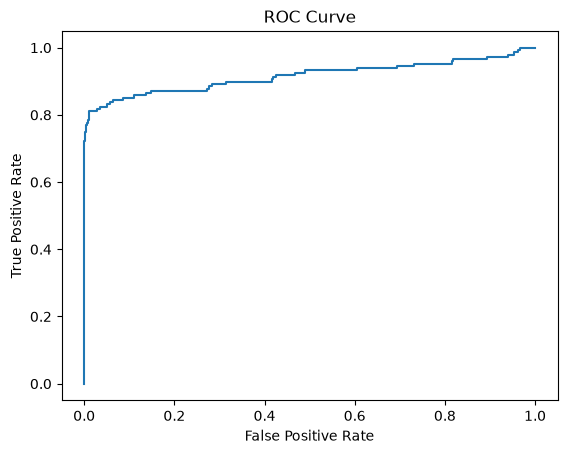

AUC: 0.9151502020808545


In [9]:
y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

print('AUC:', roc_auc_score(y_test, y_probs))


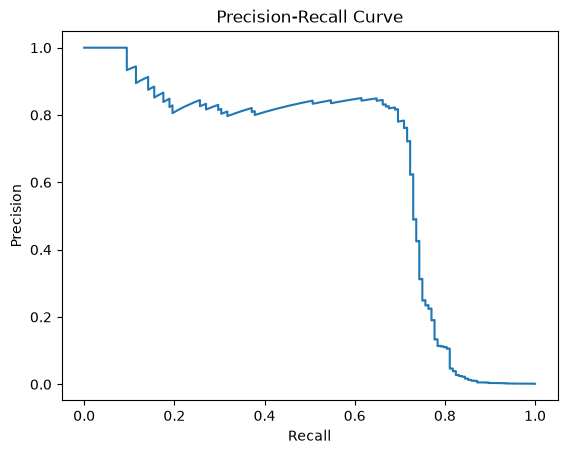

In [10]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

In [11]:
# Undersampling
fraudes = df[df['Class'] == 1]
normais = df[df['Class'] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [12]:
# Oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_res, y_res = smote.fit_resample(x, y)


In [13]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.80      0.77       148

    accuracy                           1.00     85443
   macro avg       0.87      0.90      0.89     85443
weighted avg       1.00      1.00      1.00     85443



In [18]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [17]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.68      0.74       148

    accuracy                           1.00     85443
   macro avg       0.91      0.84      0.87     85443
weighted avg       1.00      1.00      1.00     85443



# Modelo Avançado - XGBoost

XGBoost é um dos algoritmos mais usados em competições e mercado.

Ele é mais poderoso que Random Forest para muitos problemas.

In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight = 10, # Ajuda com o desbalanceamento.
    use_label_encoder = False,
    eval_metric='logloss'
)


xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

print(classification_report(y_test, y_pred_xgb))

c:\Users\eledi\OneDrive - Cruzeiro do Sul Educacional - Acadêmico\Desktop\DIO_Bradesco_GenAI_Cyber_DS\analise_fraudes\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:28:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



# Importância das Variáveis
Ajuda a entender quais variáveis influenciam mais o modelo.

Text(0.5, 1.0, 'Importâncias das Variáveis')

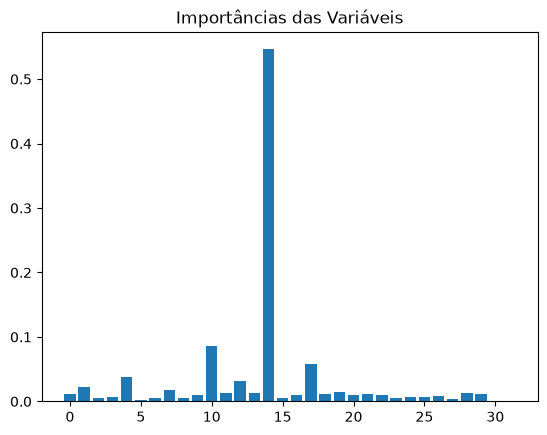

In [26]:
importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title('Importâncias das Variáveis')


# Ajuste de Hiperparâmetros
Testamos várias combinações para melhorar o modelo.

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':[3,5],
    'n_estimators': [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metrics='logloss'),
    param_grid,
    scoring='recall',
    cv=3
)

grid.fit(x_train, y_train)

print('Melhor modelo: ', grid.best_params_)

c:\Users\eledi\OneDrive - Cruzeiro do Sul Educacional - Acadêmico\Desktop\DIO_Bradesco_GenAI_Cyber_DS\analise_fraudes\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:46:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\eledi\OneDrive - Cruzeiro do Sul Educacional - Acadêmico\Desktop\DIO_Bradesco_GenAI_Cyber_DS\analise_fraudes\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:46:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\eledi\OneDrive - Cruzeiro do Sul Educacional - Acadêmico\Desktop\DIO_Bradesco_GenAI_Cyber_DS\analise_fraudes\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:46:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "eval_metrics" } are no

Melhor modelo:  {'max_depth': 5, 'n_estimators': 100}


# Explicabilidade (SHAP)
SHAP mostra como cada variável influencia a decisão do modelo.

c:\Users\eledi\OneDrive - Cruzeiro do Sul Educacional - Acadêmico\Desktop\DIO_Bradesco_GenAI_Cyber_DS\analise_fraudes\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


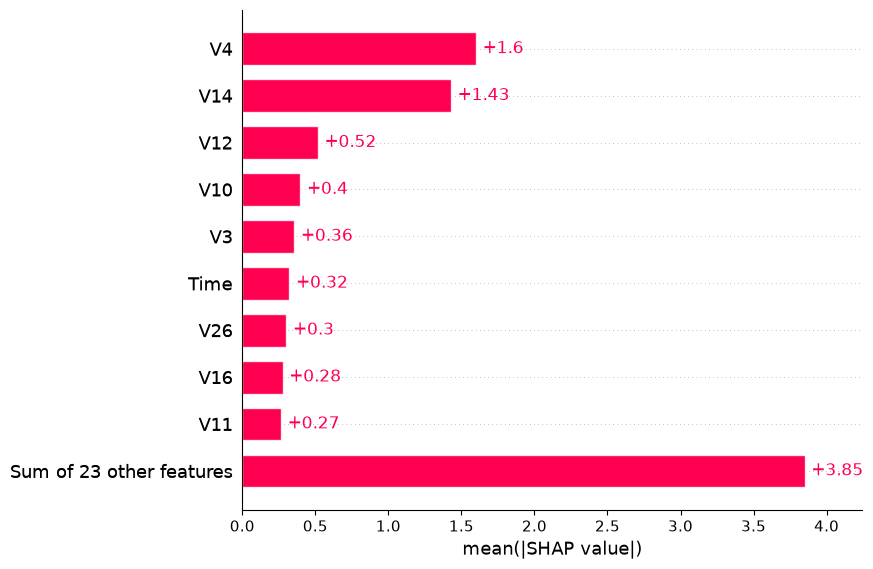

In [31]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)
